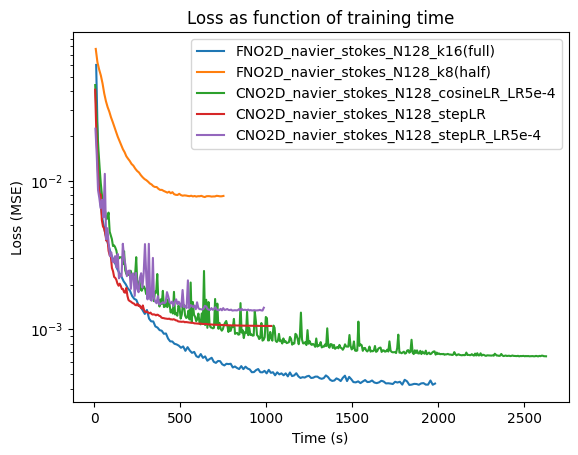

In [11]:
import numpy as np
import matplotlib.pyplot as plt

paths = ["/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N128_k16(full)_loss.csv",
         "/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N128_k8(half)_loss.csv",
         "/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N128_cosineLR_LR5e-4_loss.csv",
         "/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N128_stepLR_loss.csv",
         "/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N128_stepLR_LR5e-4_loss.csv"
         ]



fig, ax = plt.subplots(1)
ax.set_title("Loss as function of training time")
ax.set_yscale("log")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Loss (MSE)")

for path in paths:
    CNO_arr = np.loadtxt(path, delimiter = ",")

    CNO_time = CNO_arr[0, :]
    CNO_loss = CNO_arr[1, :]

    ax.plot(CNO_time, CNO_loss, label = path.rsplit("/",1)[-1].replace("_loss.csv", ""))

ax.legend()
plt.show()

In [6]:
from CNO.CNO2D_def import CNO2D
import sys
sys.path.append("/home/mnhagen/scripts/FNO")
from FNO.FNO2D_def import FNO2D
import os
import torch


res_dir = "/scratch/mnhagen/datasets/navier_stokes_multires"
res_paths = []

for filename in os.listdir(res_dir):
    res_paths.append(res_dir +"/" + filename)

res_paths = sorted(res_paths, key = lambda x: int(x.split("N")[1].split("_")[0]))
resolutions = [res_path.split("N")[1].split("_")[0] for res_path in res_paths]

CNO_path = "/scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N128_cosineLR_LR5e-4.pt"
FNO_path = "/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N128_k16(full).pt"

modes = 16
width = 128
N_layers = 4
resolution = 128
batch_size = 20
use_bn = False
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

FNO = FNO2D(modes, modes, width)
FNO.q = torch.nn.Conv2d(width, 1, 1)
FNO.load_state_dict(torch.load(FNO_path, map_location = device))

CNO = CNO2D(1, 1, resolution, N_layers, use_bn = use_bn)
CNO.load_state_dict(torch.load(CNO_path, map_location = device))

<All keys matched successfully>

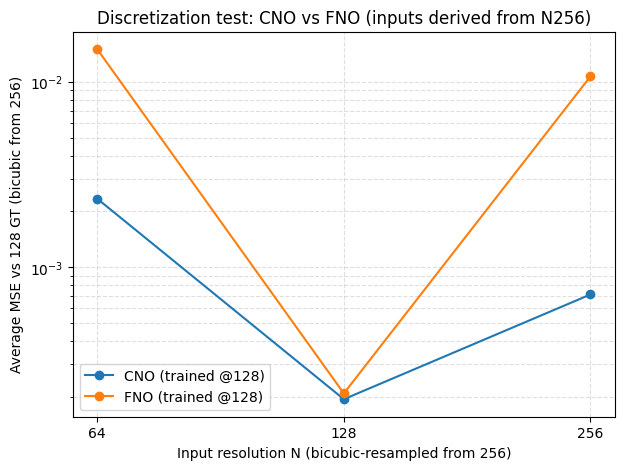

In [10]:
import h5py
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -----------------------
# Bicubic resampling
# -----------------------
def bicubic_resample_2d(x, out_h, out_w):
    # x: [B,C,H,W]
    return F.interpolate(
        x, size=(out_h, out_w),
        mode="bicubic",
        align_corners=False,
        antialias=True  # remove if your torch doesn't support it
    )

# -----------------------
# Load models
# -----------------------


# CNO (assumes you already created + loaded it earlier)
CNO = CNO.to(device).eval()

# FNO (as in your old code)
modes = 16
width = 128
FNO_path = "/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N128_k16(full).pt"

FNO = FNO2D(modes, modes, width)
FNO.q = torch.nn.Conv2d(width, 1, 1)
FNO.load_state_dict(torch.load(FNO_path, map_location=device))
FNO = FNO.to(device).eval()

# -----------------------
# Load only N=256 dataset
# -----------------------
hi_path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N256_multi.h5"
batch_size = 32
input_resolutions = [64, 128, 256]

with h5py.File(hi_path, "r") as f:
    omega = f["omega"][:]  # [n, 2, 256, 256]

i_256 = torch.tensor(omega[:, 0], dtype=torch.float32).unsqueeze(1).to(device)  # [n,1,256,256]
f_256 = torch.tensor(omega[:, 1], dtype=torch.float32).unsqueeze(1).to(device)  # [n,1,256,256]

# 128 "ground truth" derived from 256 (bicubic)
gt_128 = bicubic_resample_2d(f_256, 128, 128)  # [n,1,128,128]

# -----------------------
# Model eval helpers
# -----------------------
@torch.no_grad()
def eval_cno_curve(model):
    curve = []
    for N in input_resolutions:
        in_N = i_256 if N == 256 else bicubic_resample_2d(i_256, N, N)

        n = in_N.shape[0]
        mse_sum = 0.0

        for i in range(0, n, batch_size):
            x_b = in_N[i:i+batch_size]        # [B,1,N,N]
            y_b = gt_128[i:i+batch_size]      # [B,1,128,128]

            pred = model(x_b)                 # CNO outputs [B,1,128,128] (fixed by construction)

            per_sample_mse = (pred - y_b).pow(2).mean(dim=(1,2,3))
            mse_sum += per_sample_mse.sum().item()

        curve.append(mse_sum / n)
    return curve

@torch.no_grad()
def eval_fno_curve(model):
    curve = []
    for N in input_resolutions:
        in_N = i_256 if N == 256 else bicubic_resample_2d(i_256, N, N)  # [n,1,N,N]

        n = in_N.shape[0]
        mse_sum = 0.0

        for i in range(0, n, batch_size):
            x_b = in_N[i:i+batch_size]        # [B,1,N,N]
            y_b = gt_128[i:i+batch_size]      # [B,1,128,128]

            # FNO expects channel-last: [B,H,W,C]
            pred = model(x_b.permute(0, 2, 3, 1))   # -> [B,H,W,C]
            pred = pred.permute(0, 3, 1, 2)         # -> [B,C,H,W] = [B,1,N,N]

            # Resample prediction to 128 for fair comparison to y_b
            if pred.shape[-2:] != (128, 128):
                pred = bicubic_resample_2d(pred, 128, 128)

            per_sample_mse = (pred - y_b).pow(2).mean(dim=(1,2,3))
            mse_sum += per_sample_mse.sum().item()

        curve.append(mse_sum / n)
    return curve

# -----------------------
# Run + plot
# -----------------------
cno_curve = eval_cno_curve(CNO)
fno_curve = eval_fno_curve(FNO)

plt.figure(figsize=(7,5))
plt.plot(input_resolutions, cno_curve, marker="o", label="CNO (trained @128)")
plt.plot(input_resolutions, fno_curve, marker="o", label="FNO (trained @128)")
plt.xlabel("Input resolution N (bicubic-resampled from 256)")
plt.ylabel("Average MSE vs 128 GT (bicubic from 256)")
plt.title("Discretization test: CNO vs FNO (inputs derived from N256)")
plt.xticks(input_resolutions)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.yscale("log")
plt.xscale("log", base = 2)
plt.xticks(input_resolutions, [str(r) for r in input_resolutions])
plt.legend()
plt.show()


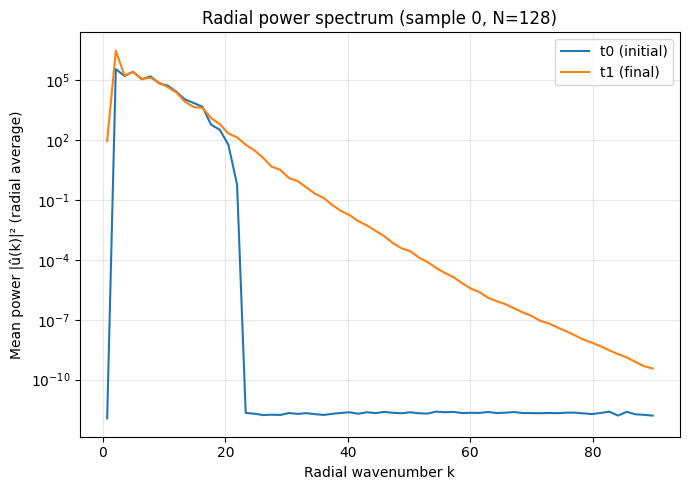

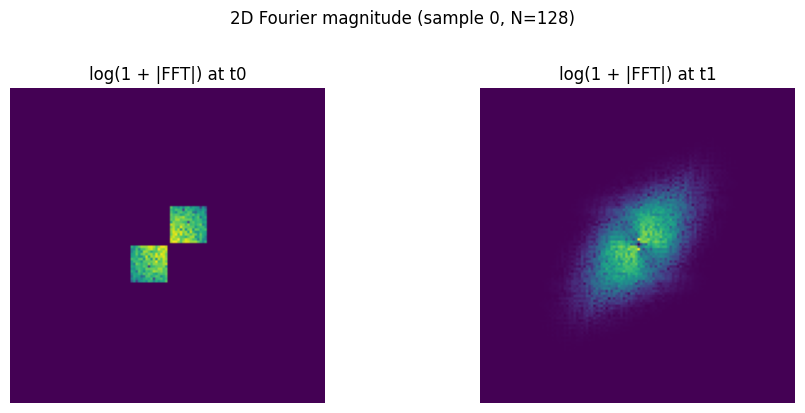

In [12]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Config
# -----------------------
h5_path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N128_multi.h5"
dataset_key = "omega"
sample_idx = 0                        
t0_idx, t1_idx = 0, 1                               

# -----------------------
# Load one sample
# -----------------------
with h5py.File(h5_path, "r") as f:
    if dataset_key not in f:
        raise KeyError(f"'{dataset_key}' not in file. Keys: {list(f.keys())}")
    # shape: (time, N, N)
    u = f[dataset_key][sample_idx]

u0 = np.array(u[t0_idx], dtype=np.float64)
u1 = np.array(u[t1_idx], dtype=np.float64)
N = u0.shape[0]

# -----------------------
# FFT helpers
# -----------------------
def fft2_logmag(u2d: np.ndarray):
    """Centered log-magnitude of the 2D FFT."""
    U = np.fft.fft2(u2d)
    U = np.fft.fftshift(U)
    return np.log1p(np.abs(U))

def radial_power_spectrum(u2d: np.ndarray, nbins=None):
    """
    Isotropic (radially averaged) power spectrum E(k) from 2D field.
    Returns k_centers, E(k) where E(k) = mean(|FFT|^2) in radial bins.
    """
    N, M = u2d.shape
    assert N == M, "Expected square field."

    U = np.fft.fft2(u2d)
    P = np.abs(U)**2

    kx = np.fft.fftfreq(N) * N
    ky = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K = np.sqrt(KX**2 + KY**2)

    if nbins is None:
        nbins = N // 2

    kmax = K.max()
    bins = np.linspace(0.0, kmax, nbins + 1)

    Kf = K.ravel()
    Pf = P.ravel()
    idx = np.digitize(Kf, bins) - 1

    E = np.zeros(nbins, dtype=np.float64)
    counts = np.zeros(nbins, dtype=np.int64)

    valid = (idx >= 0) & (idx < nbins)
    np.add.at(E, idx[valid], Pf[valid])
    np.add.at(counts, idx[valid], 1)

    mask = counts > 0
    E[mask] /= counts[mask]

    k_centers = 0.5 * (bins[:-1] + bins[1:])
    return k_centers, E

# -----------------------
# Compute spectra
# -----------------------
logmag0 = fft2_logmag(u0)
logmag1 = fft2_logmag(u1)

k0, E0 = radial_power_spectrum(u0)
k1, E1 = radial_power_spectrum(u1)

# -----------------------
# Plot radial spectra
# -----------------------
plt.figure(figsize=(7, 5))
plt.plot(k0, E0, label="t0 (initial)")
plt.plot(k1, E1, label="t1 (final)")
plt.yscale("log")
plt.xlabel("Radial wavenumber k")
plt.ylabel("Mean power |û(k)|² (radial average)")
plt.title(f"Radial power spectrum (sample {sample_idx}, N={N})")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# Plot 2D FFT log magnitude
# -----------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(logmag0, origin="lower")
plt.title("log(1 + |FFT|) at t0")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(logmag1, origin="lower")
plt.title("log(1 + |FFT|) at t1")
plt.axis("off")

plt.suptitle(f"2D Fourier magnitude (sample {sample_idx}, N={N})", y=1.02)
plt.tight_layout()
plt.show()


Notes:
1. FNO learns to output any size (?) while CNO only outputs native resolution. Makes comparison harder; for the CNO, I downsampled the greatest resolution to the desired input resolution, then compared the model prediction (always 128) to the greatest resolution downsampled to match.
2. When generating data, I generated an initial condition and solved it at each of the resolutions, which was a bad decision.